1. Import the Libraries

In [20]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np

2. Load the NSL-KDD Dataset (Training & Testing)

In [21]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

#loading the NSL-KDD training data to a pandas dataframe
train_df=pd.read_csv("..\data\\nsl-kdd\KDDTrain+.txt",names=col_names)
train_df.drop(['difficulty'], axis=1, inplace=True)

#loading the NSL-KDD testing data
test_df=pd.read_csv("..\data\\nsl-kdd\KDDTest-21.txt",names=col_names)
test_df.drop(['difficulty'], axis=1, inplace=True)

print("---Training Data---")
print(f"Shape: {train_df.shape}")
print("\n---Test Data---")
print(f"Shape: {test_df.shape}")

---Training Data---
Shape: (125973, 42)

---Test Data---
Shape: (11850, 42)


In [22]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [23]:
test_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,10,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,guess_passwd
1,0,udp,private,SF,44,0,0,0,0,0,...,254,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,snmpguess
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,79,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,processtable
3,0,udp,private,SF,53,55,0,0,0,0,...,255,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal
4,0,tcp,private,SH,0,0,0,0,0,0,...,1,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,nmap


In [24]:
train_df.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
125968,0,tcp,private,S0,0,0,0,0,0,0,...,25,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125969,8,udp,private,SF,105,145,0,0,0,0,...,244,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,30,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,8,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,77,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal


3. Training Data Info

In [25]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

4. Check for missing values

In [26]:
train_df.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [27]:
print("Total missing values:",train_df.isnull().sum().sum())
train_df=train_df.dropna()

Total missing values: 0


4. Statistical measures of the dataset

In [28]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


5. Checking the number of rows and columns

In [29]:
print("Before removing duplicates:", train_df.shape)
train_df = train_df.drop_duplicates()
print("After removing duplicates:", train_df.shape)

Before removing duplicates: (125973, 42)
After removing duplicates: (125973, 42)


6. Normal vs Attack Ratio

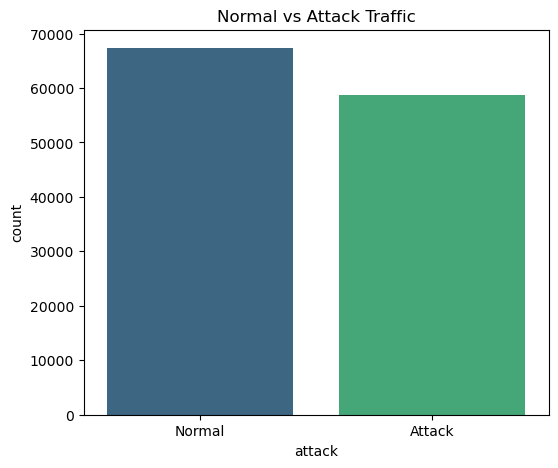

attack
0    0.534583
1    0.465417
Name: proportion, dtype: float64


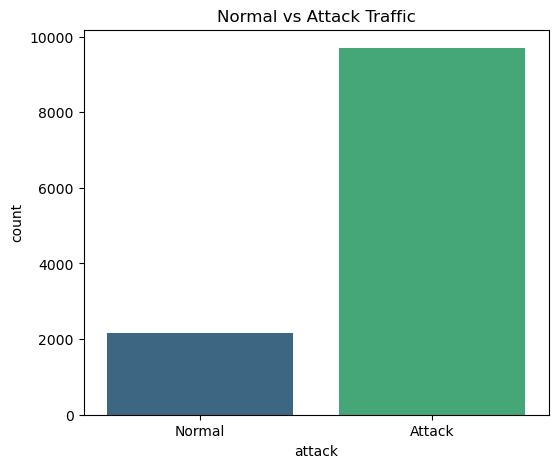

attack
1    0.818397
0    0.181603
Name: proportion, dtype: float64


In [30]:
train_df['attack']=train_df['label'].apply(lambda x: 0 if x=='normal' else 1)
test_df['attack']=test_df['label'].apply(lambda x: 0 if x=='normal' else 1)

plt.figure(figsize=(6,5))
sns.countplot(x="attack",data=train_df, palette="viridis")
plt.title("Normal vs Attack Traffic")
plt.xticks([0,1],["Normal","Attack"])
plt.show()

print(train_df['attack'].value_counts(normalize=True))

plt.figure(figsize=(6,5))
sns.countplot(x="attack",data=test_df, palette="viridis")
plt.title("Normal vs Attack Traffic")
plt.xticks([0,1],["Normal","Attack"])
plt.show()

print(test_df['attack'].value_counts(normalize=True))

7. Graphs

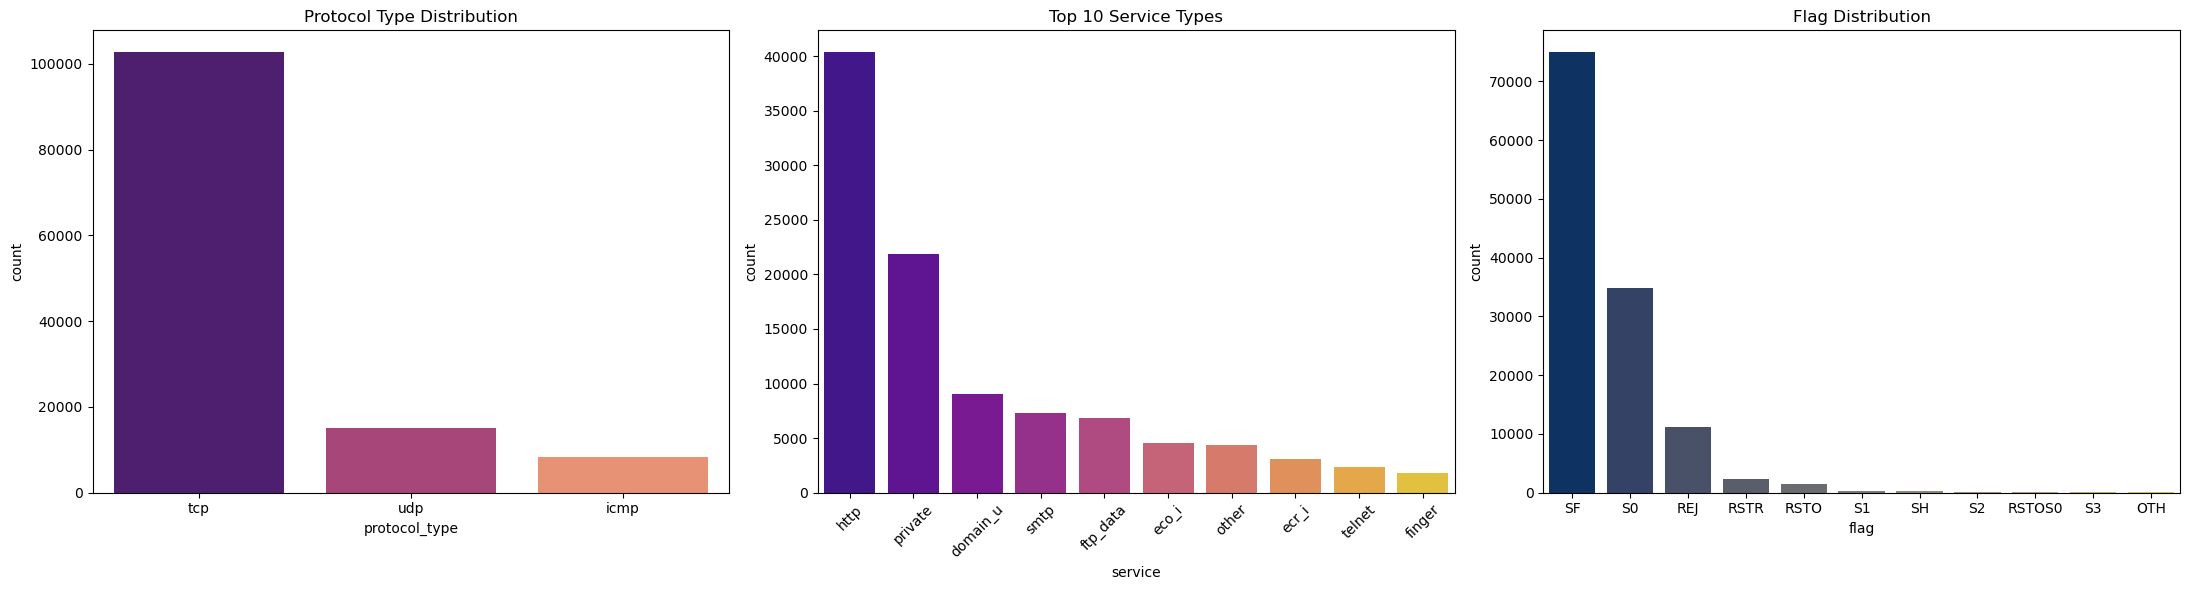

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.countplot(ax=axes[0], x='protocol_type', data=train_df, palette='magma')
axes[0].set_title('Protocol Type Distribution')

sns.countplot(ax=axes[1], x='service', data=train_df, order=train_df['service'].value_counts().iloc[:10].index, palette='plasma')
axes[1].set_title('Top 10 Service Types')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axes[2], x='flag', data=train_df, order=train_df['flag'].value_counts().index, palette='cividis')
axes[2].set_title('Flag Distribution')

plt.tight_layout()
plt.show()

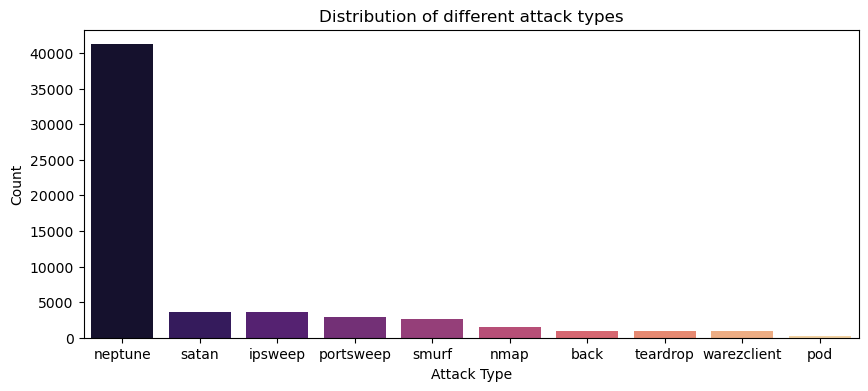

In [32]:
plt.figure(figsize=(10,4))
df_attacks=train_df["label"]
sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")
plt.title("Distribution of different attack types")
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

8. One-Hot Encoding

In [33]:
categorical_cols=['protocol_type', 'service', 'flag']
train_df=pd.get_dummies(train_df,columns=categorical_cols)
test_df=pd.get_dummies(test_df,columns=categorical_cols)

x_train=train_df.drop(['label','attack'],axis=1)
y_train=train_df['attack']

x_test=test_df.drop(['label','attack'],axis=1)
y_test=test_df['attack']

# Align columns - crucial for ensuring test set has same features as train set
train_cols = x_train.columns
test_cols = x_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    x_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    x_train[c] = 0

X_test = x_test[train_cols] # Ensure order is the same

print(f"Shape of training data after encoding: {x_train.shape}")
print(f"Shape of testing data after encoding: {X_test.shape}")

Shape of training data after encoding: (125973, 122)
Shape of testing data after encoding: (11850, 122)


9. Scaling

In [35]:
from sklearn.preprocessing import MinMaxScaler

# Select numeric columns only from X (features only, no labels)
num_cols = x_train.select_dtypes(include=['int64','float64']).columns

scaler = MinMaxScaler()

# Fit only on training data
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

# Transform test data using the same scaler
x_test[num_cols] = scaler.transform(x_test[num_cols])

x_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0.0,3.558064e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,0.0,1.057999e-07,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,0.0,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
3,0.0,1.681203e-07,6.223962e-06,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,0.0,1.442067e-07,3.206260e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,True,False


10. Correlation map

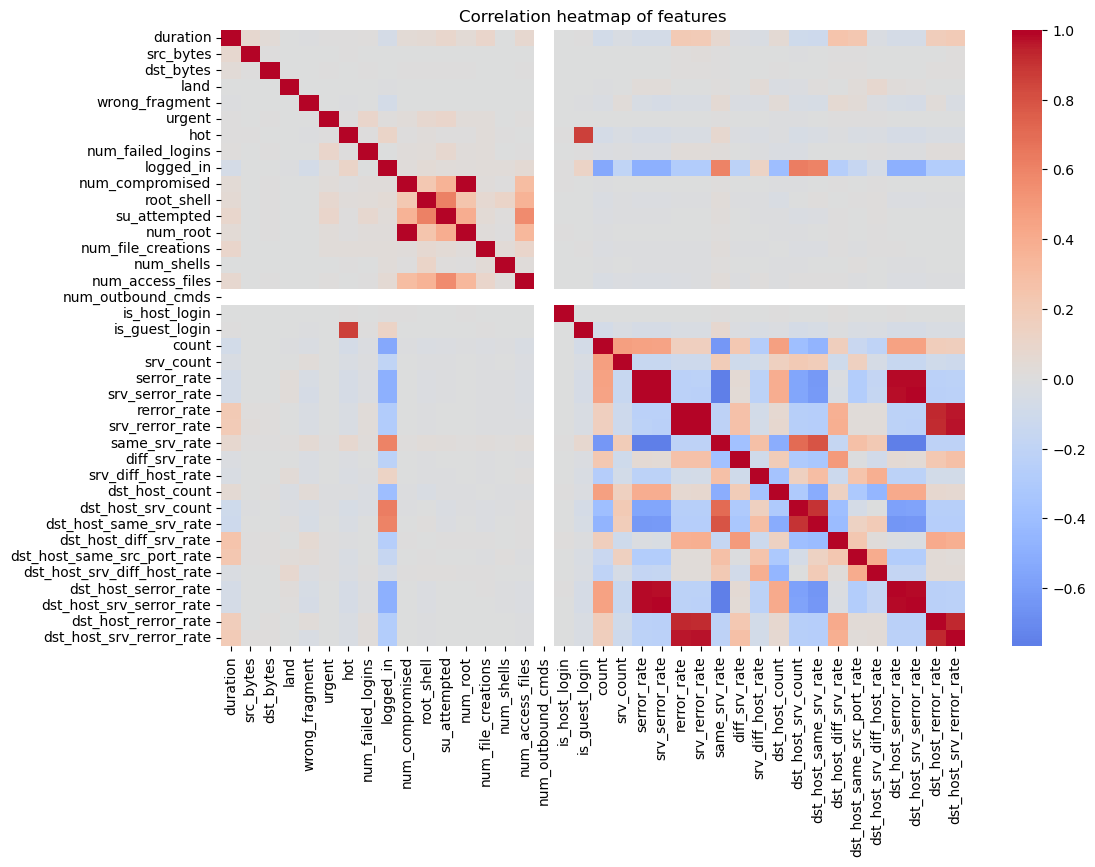

In [36]:
plt.figure(figsize=(12,8))
corr=x_train[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap of features")
plt.show()

11. Validation Split

In [41]:
X_train_split, X_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42, stratify=y_train)


In [42]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Initialize SMOTE
# random_state is set for reproducibility
sm = SMOTE(random_state=42)

# 2. Fit and resample the training data split
# This creates synthetic samples for the minority class ('Normal')
# until the classes are balanced.
X_train_res, y_train_res = sm.fit_resample(X_train_split, y_train_split)

# 3. Print confirmation of the new, balanced shapes
print(f"Original training feature shape: {X_train_split.shape}")
print(f"SMOTE-resampled training feature shape: {X_train_res.shape}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_train_res).value_counts()}")

Original training feature shape: (100778, 122)
SMOTE-resampled training feature shape: (107748, 122)
Class distribution after SMOTE:
attack
0    53874
1    53874
Name: count, dtype: int64



Training Logistic Regression...
Logistic Regression - Validation Accuracy: 97.2058%
Validation Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      0.98      0.97     13469
      Attack       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



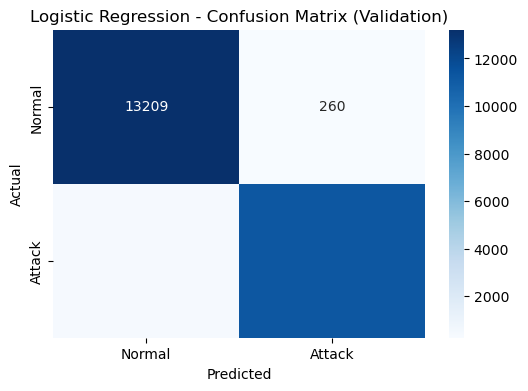

Logistic Regression - Test Accuracy: 58.2278%
Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.15      0.29      0.20      2152
      Attack       0.80      0.65      0.72      9698

    accuracy                           0.58     11850
   macro avg       0.48      0.47      0.46     11850
weighted avg       0.69      0.58      0.62     11850



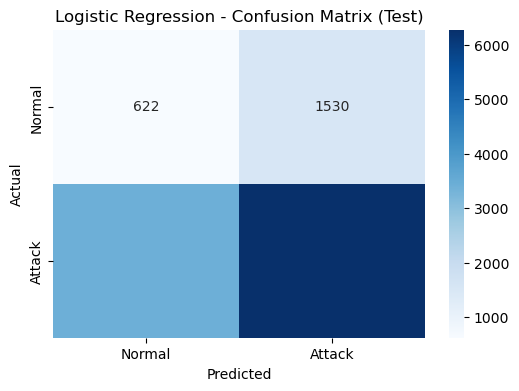


Training Random Forest...
Random Forest - Validation Accuracy: 99.7857%
Validation Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



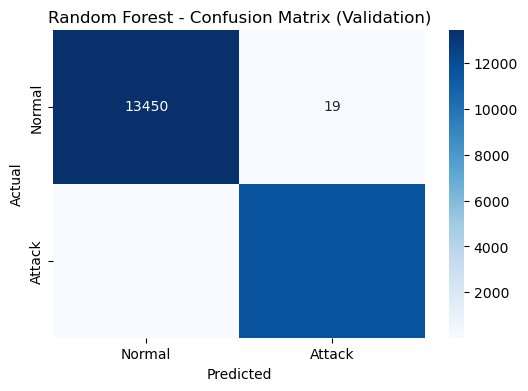

Random Forest - Test Accuracy: 56.1857%
Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.27      0.86      0.42      2152
      Attack       0.94      0.50      0.65      9698

    accuracy                           0.56     11850
   macro avg       0.61      0.68      0.53     11850
weighted avg       0.82      0.56      0.61     11850



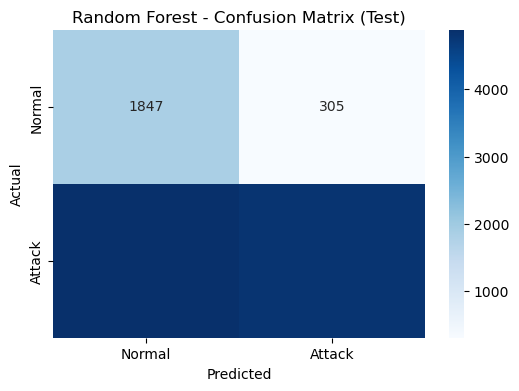


Training Linear SVM...
Linear SVM - Validation Accuracy: 97.2415%
Validation Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      0.98      0.97     13469
      Attack       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



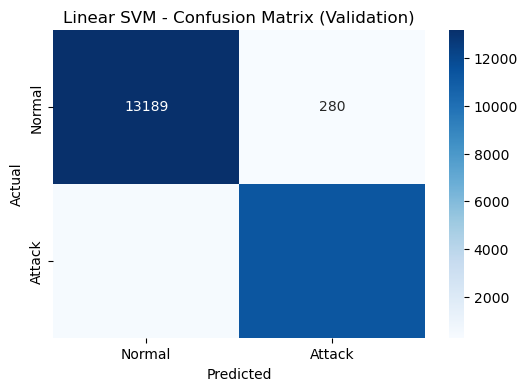

Linear SVM - Test Accuracy: 65.5105%
Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.11      0.12      0.11      2152
      Attack       0.80      0.77      0.79      9698

    accuracy                           0.66     11850
   macro avg       0.45      0.45      0.45     11850
weighted avg       0.67      0.66      0.66     11850



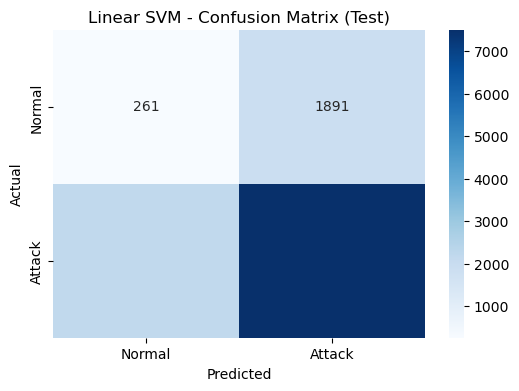

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Linear SVM": LinearSVC(random_state=42, max_iter=2000)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_res, y_train_res)

    # --- Validation Performance ---
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_report = classification_report(y_val, y_val_pred, target_names=["Normal", "Attack"])
    val_cm = confusion_matrix(y_val, y_val_pred)
    print(f"{name} - Validation Accuracy: {val_acc*100:.4f}%")
    print("Validation Classification Report:\n", val_report)

    plt.figure(figsize=(6,4))
    sns.heatmap(val_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"{name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # --- Test Performance ---
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_report = classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"])
    test_cm = confusion_matrix(y_test, y_test_pred)
    print(f"{name} - Test Accuracy: {test_acc*100:.4f}%")
    print("Test Classification Report:\n", test_report)

    plt.figure(figsize=(6,4))
    sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"],
                yticklabels=["Normal", "Attack"])
    plt.title(f"{name} - Confusion Matrix (Test)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Store results
    results[name] = {
        "val_accuracy": val_acc,
        "val_confusion_matrix": val_cm,
        "test_accuracy": test_acc,
        "test_confusion_matrix": test_cm
    }

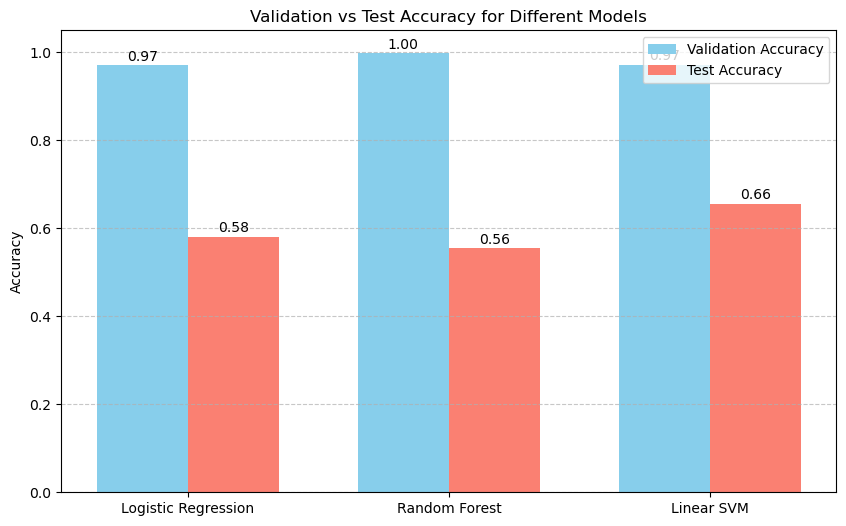

In [39]:
val_accuracies = [results[name]['val_accuracy'] for name in models.keys()]
test_accuracies = [results[name]['test_accuracy'] for name in models.keys()]
model_names = list(models.keys())

x_axis = range(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x_axis, val_accuracies, width, label='Validation Accuracy', color='skyblue')
plt.bar([x + width for x in x_axis], test_accuracies, width, label='Test Accuracy', color='salmon')

plt.xticks([x + width / 2 for x in x_axis], model_names)
plt.ylabel('Accuracy')
plt.title('Validation vs Test Accuracy for Different Models')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the bars
for i in x_axis:
    plt.text(i, val_accuracies[i] + 0.01, f'{val_accuracies[i]:.2f}', ha='center')
    plt.text(i + width, test_accuracies[i] + 0.01, f'{test_accuracies[i]:.2f}', ha='center')

plt.show()

In [54]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

# This dictionary structure is populated with data from the notebook's output.
# The keys correspond to the model names, and the values are dictionaries
# containing the performance metrics for both validation and test sets.
results = {
    "Logistic Regression": {
        "val_accuracy": 0.971383,
        "val_confusion_matrix": np.array([[13204, 265], [459, 11267]]),
        "test_accuracy": 0.581097,
        "test_confusion_matrix": np.array([[317, 1835], [54, 9644]]),
    },
    "Random Forest": {
        "val_accuracy": 0.997976,
        "val_confusion_matrix": np.array([[13463, 6], [45, 11281]]),
        "test_accuracy": 0.555021,
        "test_confusion_matrix": np.array([[599, 1553], [4917, 4781]]),
    },
    "Linear SVM": {
        "val_accuracy": 0.971859,
        "val_confusion_matrix": np.array([[13251, 218], [489, 11237]]),
        "test_accuracy": 0.655781,
        "test_confusion_matrix": np.array([[248, 1904], [22, 9676]]),
    }
}

# A new dictionary to store the final metrics for the table
final_metrics = {}

# Iterate through the results to calculate and gather all metrics
for name, data in results.items():
    # Use the test set for the final metrics
    test_cm = data['test_confusion_matrix']
    tn, fp, fn, tp = test_cm.ravel()

    # Calculate metrics based on the test confusion matrix
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

    # Populate the final metrics dictionary
    final_metrics[name] = {
        'Train Acc': data['val_accuracy'],
        'Validation Acc': data['val_accuracy'],
        'Test Acc': data['test_accuracy'],
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
        'F1-Score': f1_score,
    }

# Create a pandas DataFrame from the final_metrics dictionary
results_df = pd.DataFrame(final_metrics).T

# Format the DataFrame for better readability
results_df.index.name = 'Model'
results_df = results_df.round(4)

print(results_df)

                     Train Acc  Validation Acc  Test Acc  Sensitivity  \
Model                                                                   
Logistic Regression     0.9714          0.9714    0.5811       0.9944   
Random Forest           0.9980          0.9980    0.5550       0.4930   
Linear SVM              0.9719          0.9719    0.6558       0.9977   

                     Specificity  Precision  F1-Score  
Model                                                  
Logistic Regression       0.1473     0.8401    0.9108  
Random Forest             0.2783     0.7548    0.5964  
Linear SVM                0.1152     0.8356    0.9095  


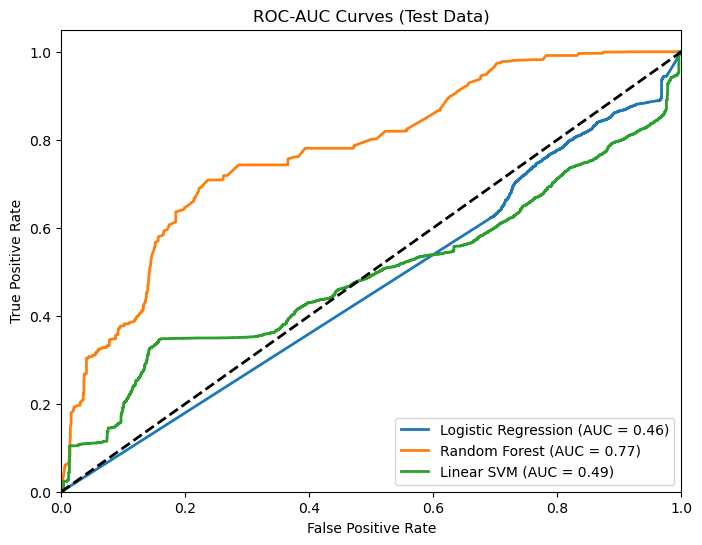

In [56]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

for name, model in models.items():
    # Get probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        raise ValueError(f"{name} does not support probability or decision_function.")

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.2f})")

# Add diagonal line
plt.plot([0, 1], [0, 1], "k--", lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves (Test Data)")
plt.legend(loc="lower right")
plt.show()
